In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA_model
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA_model
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# Cargar el dataset
df = pd.read_csv('base_primer_parcial.csv')

# revision inicial del dataset
print("Primeras filas del DataFrame:")
print(df.head())
print("\nInformación del DataFrame (Tipos de datos y valores no nulos):")
df.info()
print("\nEstadísticas descriptivas de las variables numéricas:")
print(df.describe())

Primeras filas del DataFrame:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  sales  \
0                   3              0     1                      0  sales   
1                   6              0     1                      0  sales   
2                   4              0     1                      0  sales   
3                   5              0     1                      0  sales   
4                   3              0     1                      0  sales   

   salary  
0     low  
1  mediu

In [4]:
print("\nConteo de valores faltantes por columna:")
print(df.isnull().sum())
# Si encuentra faltantes: se debe decidir si imputar (media, mediana, moda) o eliminar.



Conteo de valores faltantes por columna:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64


In [5]:
# 1. Codificación Ordinal para 'salary'
salary_map = {'low': 1, 'medium': 2, 'high': 3}
df['salary_encoded'] = df['salary'].map(salary_map)

# 2. One-Hot Encoding para 'sales' (departamento)
df_dummies = pd.get_dummies(df, columns=['sales'], prefix='dept', drop_first=True) # drop_first=True evita multicolinealidad

# Eliminar las columnas categóricas originales y la columna de salario original
df_preprocesado = df_dummies.drop(columns=['salary', 'salary_encoded']) # Mantener 'salary_encoded' para usarlo como target
df_preprocesado['salary'] = df['salary_encoded'] # Usar la codificación ordinal

print("\nColumnas después de la codificación:")
print(df_preprocesado.head())


Columnas después de la codificación:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  dept_RandD  \
0                   3              0     1                      0       False   
1                   6              0     1                      0       False   
2                   4              0     1                      0       False   
3                   5              0     1                      0       False   
4                   3              0     1                      0       Fals


---  ANÁLISIS DE CORRELACIÓN ---


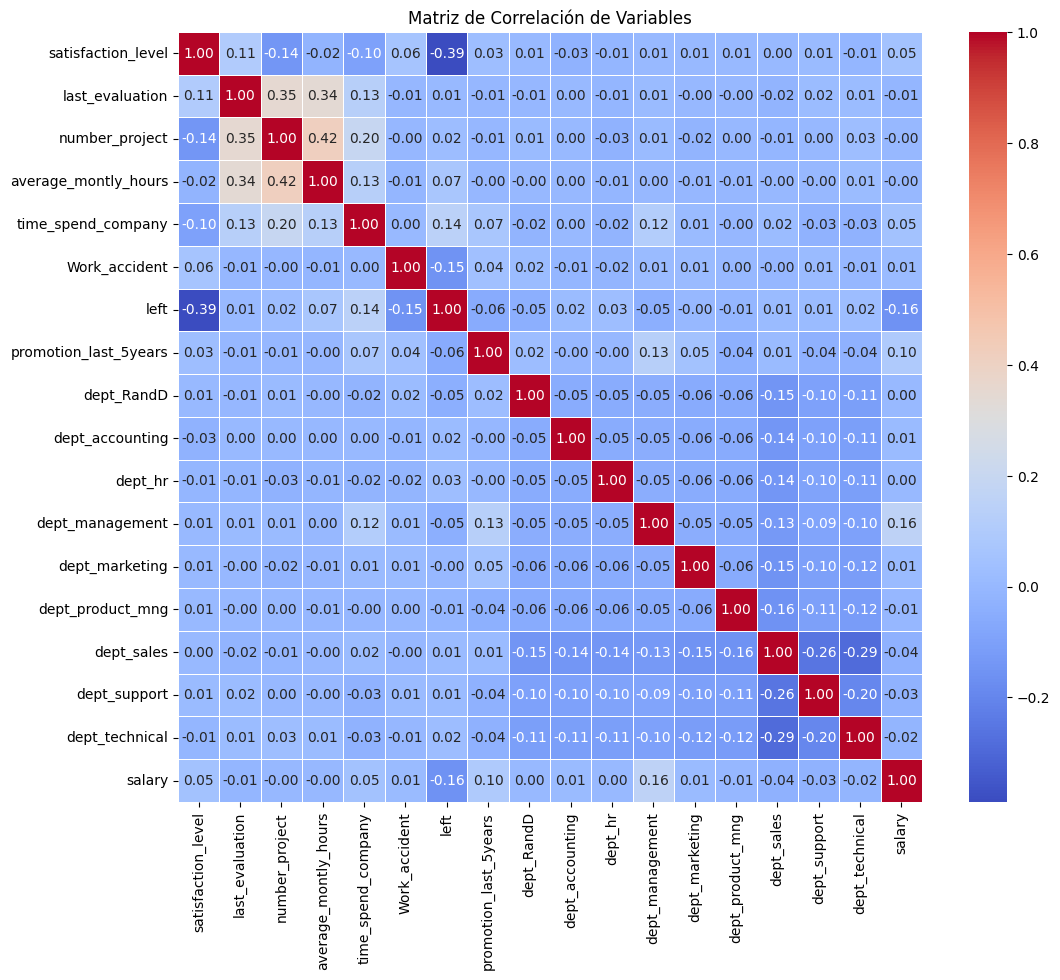

In [18]:

# MATRIZ DE CORRELACIÓN

print("\n---  ANÁLISIS DE CORRELACIÓN ---")
corr_matrix = df_preprocesado.corr()

# Visualización para el análisis de features
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables')
plt.show() 




In [7]:
clase_conteo = df_preprocesado['left'].value_counts()
print("\nBalance de Clases (Columna 'left'):")
print(clase_conteo)
tasa_rotacion = clase_conteo[1] / len(df_preprocesado)
print(f"Tasa de rotación (Clase 1): {tasa_rotacion:.2f}")

# Si el desbalance es severo (ej. < 10% o > 90%), habria que preocuparnos.


Balance de Clases (Columna 'left'):
left
0    11428
1     3571
Name: count, dtype: int64
Tasa de rotación (Clase 1): 0.24


In [8]:
# Definir X (features) e y (target)
X = df_preprocesado.drop('left', axis=1)
y = df_preprocesado['left']

# Separar conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # stratify mantiene el balance de clases

# Identificar columnas numéricas para escalar
numeric_cols = ['satisfaction_level', 'last_evaluation', 'number_project',
                'average_montly_hours', 'time_spend_company', 'Work_accident',
                'promotion_last_5years', 'salary'] # 'salary' es ordinal, pero lo incluimos en el escalado

# Crear un escalador (StandardScaler)
scaler = StandardScaler()

# Escalar solo las columnas numéricas en los conjuntos de entrenamiento y prueba
X_train_num = X_train[numeric_cols]
X_test_num = X_test[numeric_cols]

# Aplicar el escalador
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

# Convertir de nuevo a DataFrame para mantener los nombres de columnas
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numeric_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numeric_cols, index=X_test.index)

# Reintegrar las columnas binarias (dummies)
X_train_final = pd.concat([X_train_scaled_df, X_train.drop(columns=numeric_cols)], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test.drop(columns=numeric_cols)], axis=1)

# Ajustar los nombres de columnas nuevamente si hay un error en el concat
# Esto asegura que todas las columnas originales y las dummies están presentes
X_train_final = X_train_final.reindex(columns=X.columns)
X_test_final = X_test_final.reindex(columns=X.columns)

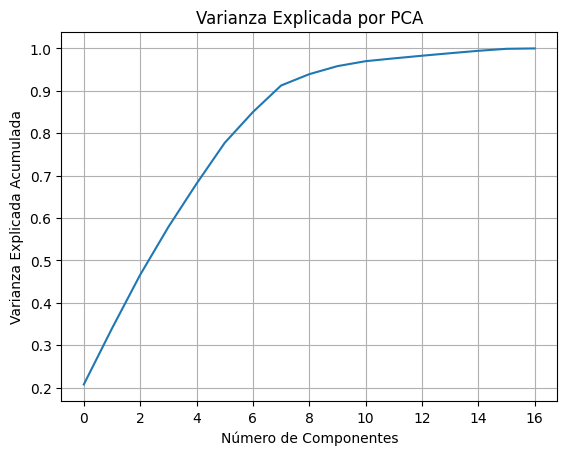


Dimensionalidad original: 17, Dimensionalidad post-PCA: 10


In [9]:
# Aplicar PCA para ver si se puede reducir la dimensionalidad
# Se usará la matriz de características escalada X_train_final
pca = PCA().fit(X_train_final)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada por PCA')
plt.grid()
plt.show() 

# Decidir el número de componentes
n_components = 10 

if n_components < X_train_final.shape[1]:
    pca_final = PCA(n_components=n_components)
    X_train_pca = pca_final.fit_transform(X_train_final)
    X_test_pca = pca_final.transform(X_test_final)
else:
    # Si no se reduce la dimensionalidad, se usan los datos escalados directamente
    X_train_pca = X_train_final
    X_test_pca = X_test_final

print(f"\nDimensionalidad original: {X_train_final.shape[1]}, Dimensionalidad post-PCA: {X_train_pca.shape[1]}")

In [10]:

print("\n---  ANÁLISIS DE PESOS DE PCA ---")
# Obtener los pesos
loadings = pd.DataFrame(pca_final.components_.T,
                        columns=[f'PC{i+1}' for i in range(pca_final.n_components)],
                        index=X_train_final.columns)

# Mostrar los pesos de las variables en el primer componente principal (el que explica más varianza)
print("Variables más influyentes en el PC1 (Mayor peso, positivo o negativo):")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))



---  ANÁLISIS DE PESOS DE PCA ---
Variables más influyentes en el PC1 (Mayor peso, positivo o negativo):
number_project          0.579157
average_montly_hours    0.549088
last_evaluation         0.506882
time_spend_company      0.314941
satisfaction_level      0.079205
Name: PC1, dtype: float64


In [11]:
def evaluar_modelo(y_true, y_pred, model_name):
    """Calcula y muestra métricas de rendimiento y la matriz de confusión."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n--- Resultados para {model_name} ---")
    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(f"Precisión (Precision): {prec:.4f}")
    print(f"Sensibilidad (Recall): {rec:.4f}")
    print("Matriz de Confusión:\n", cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot()
    plt.title(f'Matriz de Confusión: {model_name}')
    plt.show() # Muestra el gráfico 

    return {'Modelo': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec}

results = []


--- Resultados para Bayes Ingenuo ---
Exactitud (Accuracy): 0.8624
Precisión (Precision): 0.6928
Sensibilidad (Recall): 0.7582
Matriz de Confusión:
 [[3069  360]
 [ 259  812]]


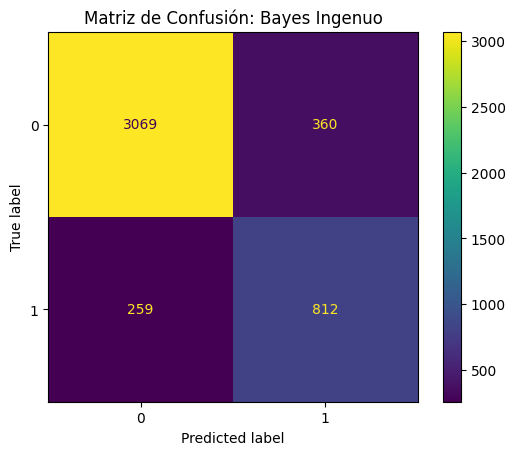

In [12]:
gnb = GaussianNB()
gnb.fit(X_train_pca, y_train)
y_pred_gnb = gnb.predict(X_test_pca)
results.append(evaluar_modelo(y_test, y_pred_gnb, "Bayes Ingenuo"))


--- Resultados para LDA ---
Exactitud (Accuracy): 0.7820
Precisión (Precision): 0.5705
Sensibilidad (Recall): 0.3399
Matriz de Confusión:
 [[3155  274]
 [ 707  364]]


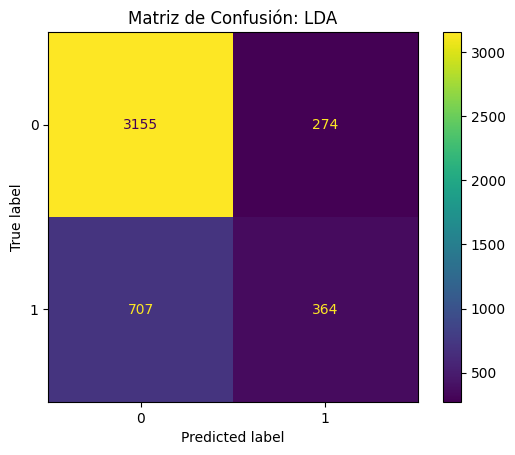

In [13]:

lda = LDA_model()
lda.fit(X_train_pca, y_train)
y_pred_lda = lda.predict(X_test_pca)
results.append(evaluar_modelo(y_test, y_pred_lda, "LDA"))


--- Resultados para QDA ---
Exactitud (Accuracy): 0.9122
Precisión (Precision): 0.7793
Sensibilidad (Recall): 0.8805
Matriz de Confusión:
 [[3162  267]
 [ 128  943]]


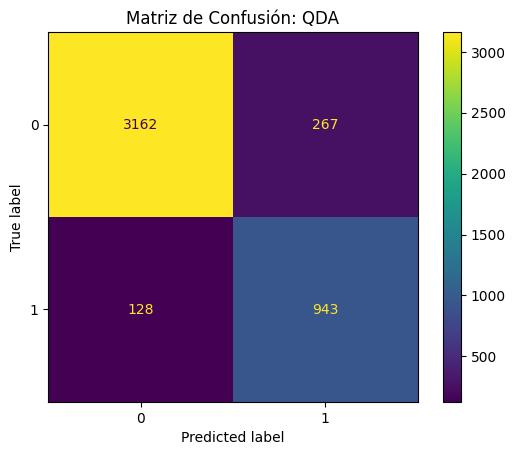

In [14]:
qda = QDA_model()
qda.fit(X_train_pca, y_train)
y_pred_qda = qda.predict(X_test_pca)
results.append(evaluar_modelo(y_test, y_pred_qda, "QDA"))


--- Resultados para SVM (RBF) ---
Exactitud (Accuracy): 0.9647
Precisión (Precision): 0.9376
Sensibilidad (Recall): 0.9122
Matriz de Confusión:
 [[3364   65]
 [  94  977]]


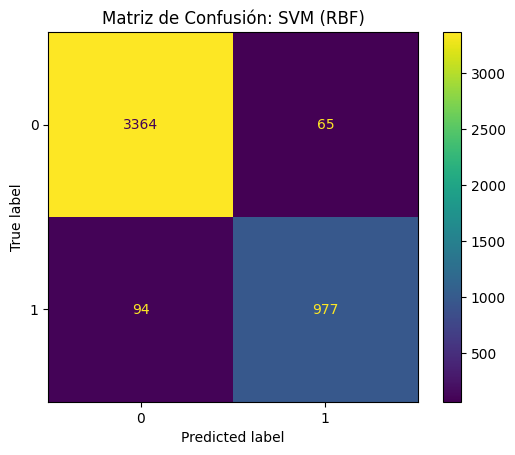

In [15]:
# Usar un kernel lineal o RBF
svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_train_pca, y_train)
y_pred_svc = svc.predict(X_test_pca)
results.append(evaluar_modelo(y_test, y_pred_svc, "SVM (RBF)"))


--- Resumen de Métricas de los Modelos ---
          Modelo  Accuracy  Precision    Recall
0  Bayes Ingenuo  0.862444   0.692833  0.758170
1            LDA  0.782000   0.570533  0.339869
2            QDA  0.912222   0.779339  0.880486
3      SVM (RBF)  0.964667   0.937620  0.912232


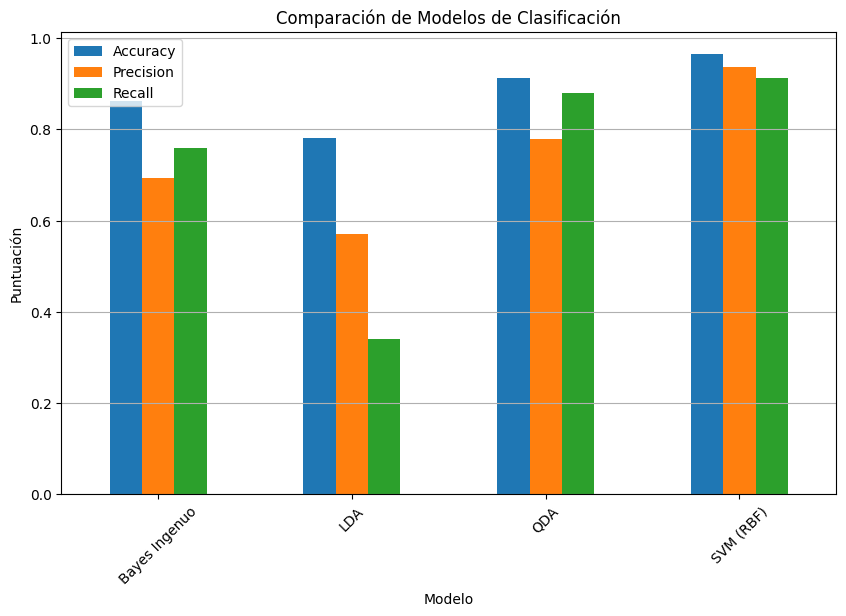

In [16]:
# Convertir los resultados a un DataFrame para una fácil comparación
results_df = pd.DataFrame(results)
print("\n--- Resumen de Métricas de los Modelos ---")
print(results_df)

# Gráfico de barras para comparar métricas
results_df.set_index('Modelo').plot(kind='bar', figsize=(10, 6))
plt.title('Comparación de Modelos de Clasificación')
plt.ylabel('Puntuación')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show() # Muestra el gráfico 


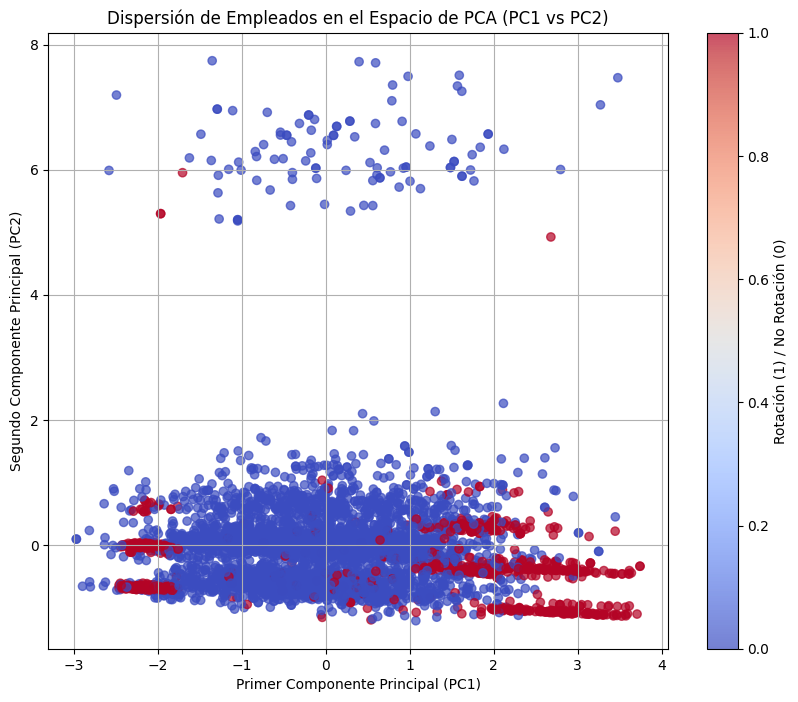

In [17]:

# Reajustar PCA para asegurar que tengamos al menos 2 componentes para la gráfica
pca_2d = PCA(n_components=2)
X_test_pca_2d = pca_2d.fit_transform(X_test_final)

plt.figure(figsize=(10, 8))
# Gráfico de dispersión de los datos de prueba proyectados en los dos componentes
scatter = plt.scatter(X_test_pca_2d[:, 0], X_test_pca_2d[:, 1], c=y_test, cmap='coolwarm', alpha=0.7)

plt.title('Dispersión de Empleados en el Espacio de PCA (PC1 vs PC2)')
plt.xlabel('Primer Componente Principal (PC1)')
plt.ylabel('Segundo Componente Principal (PC2)')
plt.colorbar(scatter, label='Rotación (1) / No Rotación (0)')
plt.grid(True)
plt.show()